<a href="https://colab.research.google.com/github/LielUziahu/L.Uziahu_Lab_Notebook-Mass_Lab/blob/master/FIRe_Temp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:81: SyntaxWarning: invalid escape sequence '\s'
<>:81: SyntaxWarning: invalid escape sequence '\s'
<>:81: SyntaxWarning: invalid escape sequence '\s'
<>:81: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-4222890571.py:81: SyntaxWarning: invalid escape sequence '\s'
  {"col": "Sigma", "ylabel": "$\sigma_{PSII}$ ($\AA^2$)", "title": "Effective Cross-section ($\sigma_{PSII}$)\nunder different temperatures", "tick_spacing": 200.0}
/tmp/ipython-input-4222890571.py:81: SyntaxWarning: invalid escape sequence '\s'
  {"col": "Sigma", "ylabel": "$\sigma_{PSII}$ ($\AA^2$)", "title": "Effective Cross-section ($\sigma_{PSII}$)\nunder different temperatures", "tick_spacing": 200.0}



Analysis for Fm:
         Factor   P-value Significance
0        Morph  0.921031           ns
1         Temp  0.399449           ns
2  Interaction  0.000728          ***


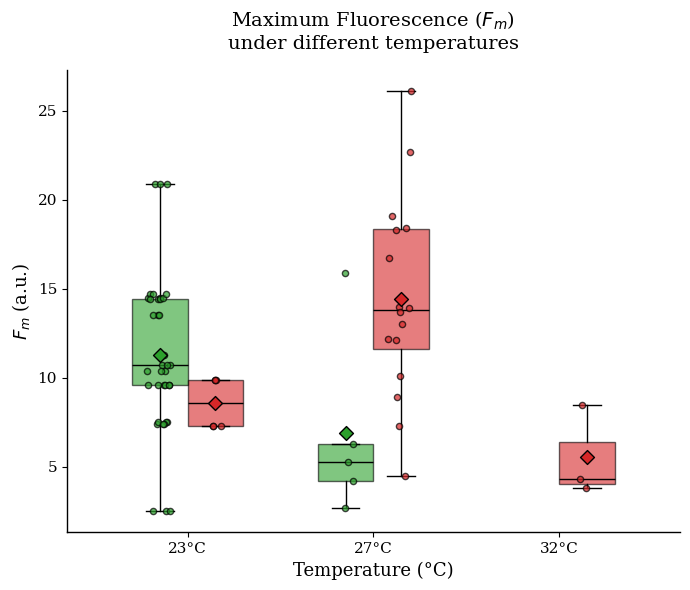


Analysis for fv_fm:
         Factor   P-value Significance
0        Morph  0.519227           ns
1         Temp  0.713845           ns
2  Interaction  0.986198           ns


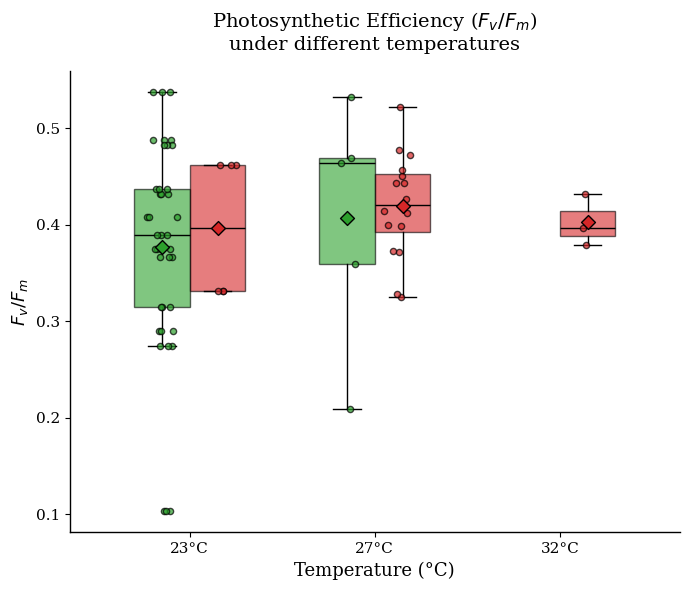


Analysis for Pmax.e.s:
         Factor   P-value Significance
0        Morph  0.312867           ns
1         Temp  0.888837           ns
2  Interaction  0.081964           ns


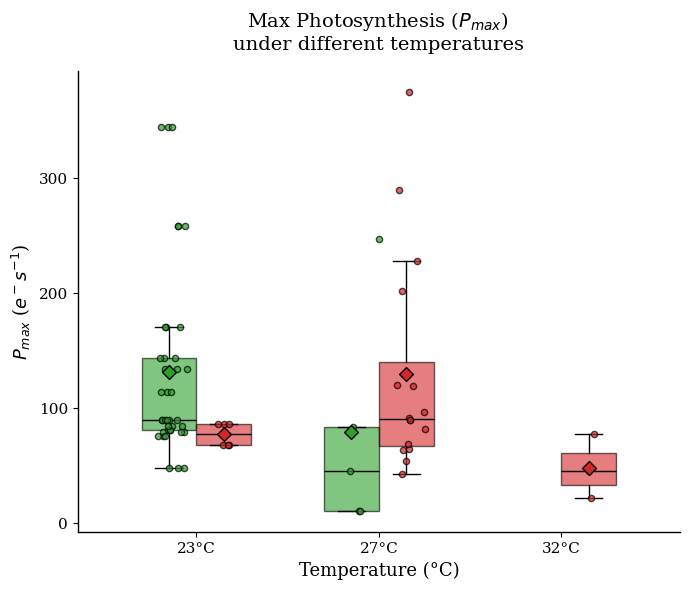


Analysis for p:
         Factor   P-value Significance
0        Morph  0.676451           ns
1         Temp  0.990079           ns
2  Interaction  0.430292           ns


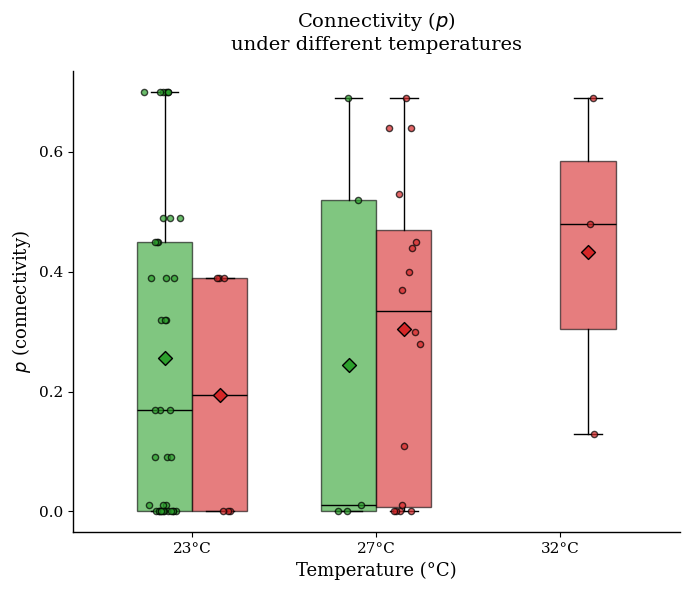


Analysis for Sigma:
         Factor   P-value Significance
0        Morph  0.118796           ns
1         Temp  0.747874           ns
2  Interaction  0.491161           ns


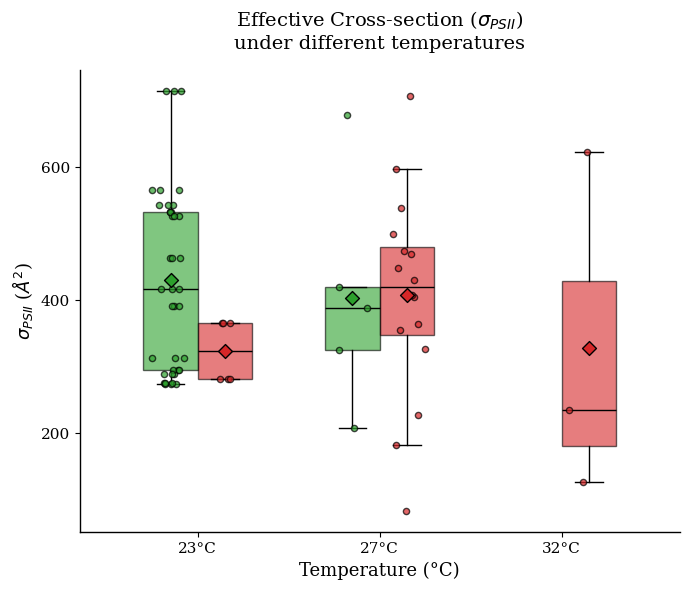

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ==========================================
# 1. GLOBAL SETUP & DATA LOADING
# ==========================================
filename = "FIRe_2025_Temp.csv"
df = pd.read_csv(filename)

# Clean columns
df.columns = df.columns.str.strip()
if 'Site' in df.columns:
    df = df.rename(columns={'Site': 'morph'})
df['morph'] = df['morph'].str.strip()

# Clean Temp column and set order
df['Temp'] = df['Temp'].astype(str).str.strip()
temp_order = ["23", "27", "32"]
df = df[df['Temp'].isin(temp_order)]

# --- DATA CLEANING (Global Filters) ---
if 'p' in df.columns:
    df = df[df['p'] <= 0.8].copy()

if 'Pmax.e.s' in df.columns:
    df = df[df['Pmax.e.s'] <= 450].copy()

if 'Sigma' in df.columns:
    df = df[df['Sigma'] <= 850].copy()

if 'fv_fm' in df.columns:
    df = df[df['fv_fm'] > 0].copy()

# Style Settings
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}
morph_order = ["HF", "NF"]

def generate_stats_table_2way(dataframe, col):
    """Calculates Two-Way ANOVA stats for Temperature and Morph."""
    try:
        model = ols(f"Q('{col}') ~ C(morph) + C(Temp) + C(morph):C(Temp)", data=dataframe).fit()
        anova = sm.stats.anova_lm(model, typ=2)
        p_morph = anova.loc['C(morph)', 'PR(>F)']
        p_temp = anova.loc['C(Temp)', 'PR(>F)']
        p_inter = anova.loc['C(morph):C(Temp)', 'PR(>F)']

        return pd.DataFrame({
            'Factor': ['Morph', 'Temp', 'Interaction'],
            'P-value': [p_morph, p_temp, p_inter],
            'Significance': [
                "ns" if p >= 0.05 else ("*" if p >= 0.01 else ("**" if p >= 0.001 else "***"))
                for p in [p_morph, p_temp, p_inter]
            ]
        })
    except Exception as e:
        return pd.DataFrame({'Error': [str(e)]})

# Plot Configuration
plots_config = [
    {"col": "Fm", "ylabel": "$F_m$ (a.u.)", "title": "Maximum Fluorescence ($F_m$)\nunder different temperatures", "tick_spacing": 5.0},
    {"col": "fv_fm", "ylabel": "$F_v/F_m$", "title": "Photosynthetic Efficiency ($F_v/F_m$)\nunder different temperatures", "tick_spacing": 0.1},
    {"col": "Pmax.e.s", "ylabel": "$P_{max}$ ($e^- s^{-1}$)", "title": "Max Photosynthesis ($P_{max}$) \nunder different temperatures", "tick_spacing": 100.0},
    {"col": "p", "ylabel": "$p$ (connectivity)", "title": "Connectivity ($p$)\nunder different temperatures", "tick_spacing": 0.2},
    {"col": "Sigma", "ylabel": "$\sigma_{PSII}$ ($\AA^2$)", "title": "Effective Cross-section ($\sigma_{PSII}$)\nunder different temperatures", "tick_spacing": 200.0}
]

for config in plots_config:
    col = config["col"]
    if col not in df.columns: continue

    sub = df.dropna(subset=[col, 'morph', 'Temp'])
    sub = sub[sub['morph'].isin(morph_order)]

    # Statistics
    stats_df = generate_stats_table_2way(sub, col)
    print(f"\nAnalysis for {col}:\n", stats_df)

    # Plotting
    fig, ax = plt.subplots(figsize=(7, 6))
    box_width, x_pos = 0.6, np.arange(len(temp_order))
    offset = box_width / 4

    # Boxes for HF and NF
    for m, off in [('HF', -offset), ('NF', offset)]:
        data = [sub[(sub['Temp']==t) & (sub['morph']==m)][col].values for t in temp_order]
        bp = ax.boxplot(data, positions=x_pos + off, widths=box_width/2, patch_artist=True, showfliers=False)
        for patch in bp['boxes']:
            patch.set(facecolor=variant_colors[m], alpha=0.6, edgecolor='black')
        plt.setp(bp['medians'], color='black')

    # Scatter points & Means
    for i, temp_val in enumerate(temp_order):
        for m, off in [('HF', -offset), ('NF', offset)]:
            y = sub[(sub['Temp']==temp_val) & (sub['morph']==m)][col]
            ax.scatter(np.random.normal(i + off, 0.04, size=len(y)), y, s=20, color=variant_colors[m], edgecolors='black', alpha=0.7, zorder=3)
            if not y.empty:
                ax.scatter(i + off, y.mean(), marker='D', s=50, color=variant_colors[m], edgecolors='black', zorder=4)

    # Labels & Formatting
    ax.set_ylabel(config["ylabel"], fontsize=13)
    ax.set_xlabel("Temperature (°C)", fontsize=13)
    ax.set_title(config["title"], fontsize=14, pad=15)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{t}°C" for t in temp_order])

    # Morph Significance Annotation
    p_morph = stats_df.loc[stats_df['Factor']=='Morph', 'P-value'].values[0]
    if p_morph < 0.05:
        p_text = f"p(morph) = {p_morph:.3f}" if p_morph >= 0.001 else "p(morph) < 0.001"
        ax.text(0.95, 0.05, p_text, transform=ax.transAxes, ha='right', va='bottom', fontsize=10, style='italic')

    ax.yaxis.set_major_locator(ticker.MultipleLocator(config["tick_spacing"]))
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(f"FIRe_Temp_{col}.png", dpi=300)
    plt.show()